C:\Users\Acer\anaconda3\python.exe
Using Device: cpu
Epoch 1/3 | Loss: 317.4350
Epoch 2/3 | Loss: 82.3364
Epoch 3/3 | Loss: 59.7811

Test Accuracy: 98.50%
Model Saved


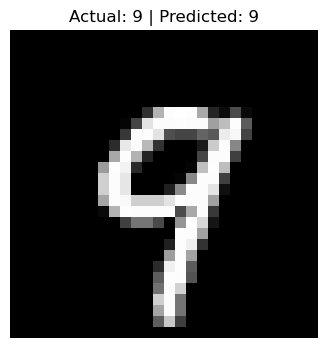

Selected Image Index: 12
Actual Label: 9
Predicted Label: 9


In [12]:
import sys
print(sys.executable)

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

transform = transforms.ToTensor()

train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 3

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}"
    )

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print(f"\nTest Accuracy: {accuracy:.2f}%")

torch.save(
    model.state_dict(),
    "simple_cnn_mnist.pth"
)

print("Model Saved")

index = 12

image, true_label = test_data[index]

image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    output = model(image_input)

    predicted_label = output.argmax(dim=1).item()

plt.figure(figsize=(4,4))
plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Actual: {true_label} | Predicted: {predicted_label}"
)

plt.axis("off")
plt.show()

print("Selected Image Index:", index)
print("Actual Label:", true_label)
print("Predicted Label:", predicted_label)